# Add a New Class to the Prototype Recognition System

## What this notebook does

This notebook extends an already-trained 5-class system (leather, tile, wood, grid, carpet) by adding one new class. The original dataset is NOT required.

The backbone is kept frozen. We only extract embeddings for the new class images and compute K-Means centroids, then append them to the existing multi-prototype bank. This avoids catastrophic forgetting without any retraining.

Steps:
1. Load the existing backbone (resnet18_backbone.pth) - frozen, no training
2. Load the existing bank (bank_resnet_multi_proto.pth) - has 5 classes already
3. Extract embeddings for the new class images
4. Run K-Means to compute K centroids for the new class
5. Add those centroids to the bank and save both files in-place
6. Evaluate on a test set with F1, accuracy, macro-average and per-sample confidence
7. Train a STFPM anomaly detector for the new class

## Prerequisites
- Google Drive mounted with your existing checkpoints
- Images of your new class (no labels needed, just normal/good images)
- GPU runtime recommended (Runtime - Change runtime type - T4 GPU)

---

## STEP 1 - Install Dependencies and Mount Drive

In [1]:
import subprocess, sys

packages = [
    'torch', 'torchvision', 'opencv-python',
    'scikit-learn', 'matplotlib', 'seaborn',
    'pandas', 'numpy', 'Pillow', 'tqdm', 'tabulate',
    'anomalib'
]
for pkg in packages:
    try:
        __import__(pkg.replace('-', '_').split('==')[0])
    except ImportError:
        print(f'Installing {pkg} ...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('All packages ready.')

Installing opencv-python ...
Installing scikit-learn ...
Installing Pillow ...
Installing anomalib ...
All packages ready.


In [2]:
from google.colab import drive
drive.mount('/content/drive')
print('Google Drive mounted.')

Mounted at /content/drive
Google Drive mounted.


## STEP 2 - Configuration

Edit the paths in this cell before running anything else.

**You must set:**
- `DATASET_ROOT` - folder containing your new class images
- `CHECKPOINT_DIR` - folder where resnet18_backbone.pth and bank_resnet_multi_proto.pth live
- `STFPM_MODEL_DIR` - folder where anomaly .ckpt files are saved
- `LOG_DIR` - folder for training logs

**Dataset layout expected for new class (either layout works):**

Flat layout - the notebook will auto-split 85/15:
```
DATASET_ROOT/
  <new_class_name>/
    image1.jpg
    image2.jpg
    ...
```

Pre-split layout:
```
DATASET_ROOT/
  <new_class_name>/
    train/good/
      image1.jpg ...
    test/good/
      image2.jpg ...
```

In [3]:
# -----------------------------------------------------------------------
# USER CONFIGURATION - Edit paths below before running
# -----------------------------------------------------------------------

# Folder containing your new class images
DATASET_ROOT = '/content/drive/MyDrive/Colab Notebooks/ICT304/dataset'

# Folder where resnet18_backbone.pth and bank_resnet_multi_proto.pth are saved
CHECKPOINT_DIR = '/content/drive/MyDrive/Colab Notebooks/ICT304/future_integration/models'

# Folder where STFPM anomaly .ckpt files are saved
STFPM_MODEL_DIR = '/content/drive/MyDrive/Colab Notebooks/ICT304/future_integration/models/stfpm'

# Folder for STFPM training logs
LOG_DIR = '/content/drive/MyDrive/Colab Notebooks/ICT304/future_integration/models/stfpm/new_class'

# Model file names - change only if yours differ
BACKBONE_FILENAME = 'resnet18_backbone.pth'
BANK_FILENAME     = 'bank_resnet18_multi_proto.pth'

# Original 5 classes - do NOT change
ORIGINAL_CLASSES = ['leather', 'tile', 'wood', 'grid', 'carpet']

# -----------------------------------------------------------------------
# NOTHING BELOW THIS LINE NEEDS TO BE CHANGED
# -----------------------------------------------------------------------

import os
os.makedirs(CHECKPOINT_DIR,  exist_ok=True)
os.makedirs(STFPM_MODEL_DIR, exist_ok=True)
os.makedirs(LOG_DIR,         exist_ok=True)

BACKBONE_PATH = os.path.join(CHECKPOINT_DIR, BACKBONE_FILENAME)
BANK_PATH     = os.path.join(CHECKPOINT_DIR, BANK_FILENAME)

print('Paths configured:')
print(f'  Dataset root    : {DATASET_ROOT}')
print(f'  Checkpoint dir  : {CHECKPOINT_DIR}')
print(f'  Backbone file   : {BACKBONE_PATH}')
print(f'  Bank file       : {BANK_PATH}')
print(f'  STFPM model dir : {STFPM_MODEL_DIR}')

missing = [p for p in [BACKBONE_PATH, BANK_PATH] if not os.path.exists(p)]
if missing:
    print('\nWARNING - the following model files were not found:')
    for m in missing:
        print(f'  {m}')
    print('  Make sure CHECKPOINT_DIR is correct and the files exist before continuing.')
else:
    print('\nExisting model files found - ready to proceed.')

Paths configured:
  Dataset root    : /content/drive/MyDrive/Colab Notebooks/ICT304/dataset
  Checkpoint dir  : /content/drive/MyDrive/Colab Notebooks/ICT304/future_integration/models
  Backbone file   : /content/drive/MyDrive/Colab Notebooks/ICT304/future_integration/models/resnet18_backbone.pth
  Bank file       : /content/drive/MyDrive/Colab Notebooks/ICT304/future_integration/models/bank_resnet18_multi_proto.pth
  STFPM model dir : /content/drive/MyDrive/Colab Notebooks/ICT304/future_integration/models/stfpm

Existing model files found - ready to proceed.


## STEP 3 - Name the New Class

Type the name of your new class in the input prompt below.  
The name must match the subfolder name inside `DATASET_ROOT`.

In [4]:
from pathlib import Path

available = [d.name for d in Path(DATASET_ROOT).iterdir() if d.is_dir()] \
            if Path(DATASET_ROOT).exists() else []

if available:
    print('Folders found in DATASET_ROOT:')
    for a in available:
        print(f'  {a}')
else:
    print(f'WARNING: No subfolders found in {DATASET_ROOT}')

NEW_CLASS = input('\nEnter the new class name (must match subfolder): ').strip().lower()

if not NEW_CLASS:
    raise ValueError('Class name cannot be empty.')
if NEW_CLASS in ORIGINAL_CLASSES:
    raise ValueError(f'"{NEW_CLASS}" already exists in the 5-class system. Choose a different name.')

ALL_CLASSES  = sorted(ORIGINAL_CLASSES + [NEW_CLASS])
CLASS_TO_IDX = {cls: i for i, cls in enumerate(ALL_CLASSES)}
IDX_TO_CLASS = {v: k for k, v in CLASS_TO_IDX.items()}
NUM_CLASSES  = len(ALL_CLASSES)

print(f'\nNew class  : {NEW_CLASS}')
print(f'All classes: {ALL_CLASSES}')
print(f'Total      : {NUM_CLASSES} classes')

Folders found in DATASET_ROOT:
  bottle
  cable
  capsule
  carpet
  grid
  hazelnut
  leather
  metal_nut
  pill
  screw
  tile
  toothbrush
  transistor
  wood
  zipper
  checkpoints
  results

Enter the new class name (must match subfolder): bottle

New class  : bottle
All classes: ['bottle', 'carpet', 'grid', 'leather', 'tile', 'wood']
Total      : 6 classes


## STEP 4 - All Imports, Transforms, Dataset Utilities and Model

This single cell contains all imports, transforms, dataset classes, model architecture and the PrototypeBank class.  
Run it once and all components will be available for the steps below.

In [5]:
import os, random, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tabulate import tabulate
from PIL import Image
from tqdm.notebook import tqdm
from pathlib import Path
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, precision_score, recall_score, accuracy_score
)
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
print(f'PyTorch: {torch.__version__}')

# -----------------------------------------------------------------------
# Hyperparameters - same as original 5-class training
# -----------------------------------------------------------------------
IMG_SIZE             = 224
EMBEDDING_DIM        = 128
DROPOUT              = 0.2
BATCH_SIZE           = 64
CONFIDENCE_THRESHOLD = 0.98
MARGIN_THRESHOLD     = 0.05
N_PROTOTYPES         = 3     # K per class in multi-prototype bank

print('Hyperparameters loaded.')

# -----------------------------------------------------------------------
# Transforms
# -----------------------------------------------------------------------
_MEAN = [0.485, 0.456, 0.406]
_STD  = [0.229, 0.224, 0.225]

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(_MEAN, _STD),
])

print('Transforms ready.')

# -----------------------------------------------------------------------
# Dataset utilities
# -----------------------------------------------------------------------
EXTS = {'.png', '.jpg', '.jpeg', '.bmp'}

def iter_images(folder):
    folder = Path(folder)
    if not folder.exists():
        return []
    return [p for p in folder.iterdir() if p.suffix.lower() in EXTS]


def collect_new_class_images(dataset_root, cls_name):
    """
    Auto-detects flat or MVTec layout for the new class.
    Returns (train_samples, test_samples) as lists of (path, cls_name).
    """
    root = Path(dataset_root) / cls_name
    if not root.exists():
        raise FileNotFoundError(
            f'Folder not found: {root}\n'
            f'Make sure DATASET_ROOT contains a subfolder named "{cls_name}"'
        )

    train_good = root / 'train' / 'good'
    test_good  = root / 'test'  / 'good'

    if train_good.exists() and test_good.exists():
        train_imgs = iter_images(train_good)
        test_imgs  = iter_images(test_good)
        print(f'  Pre-split layout detected.')
        print(f'  Train: {len(train_imgs)}  |  Test: {len(test_imgs)}')
        return ([(str(p), cls_name) for p in train_imgs],
                [(str(p), cls_name) for p in test_imgs])
    else:
        all_imgs = iter_images(root)
        if not all_imgs:
            for sub in root.iterdir():
                if sub.is_dir():
                    all_imgs.extend(iter_images(sub))
        if not all_imgs:
            raise FileNotFoundError(
                f'No images found in {root}. Supported formats: {EXTS}'
            )
        print(f'  Flat layout detected - auto-splitting {len(all_imgs)} images (85% train / 15% test).')
        paths_str = [str(p) for p in all_imgs]
        tr, te = train_test_split(paths_str, test_size=0.15, random_state=SEED)
        print(f'  Train: {len(tr)}  |  Test: {len(te)}')
        return [(p, cls_name) for p in tr], [(p, cls_name) for p in te]


class SimpleDataset(Dataset):
    """Single image + label dataset used for embedding extraction and evaluation."""

    def __init__(self, samples, class_to_idx, transform=None):
        self.samples      = samples
        self.class_to_idx = class_to_idx
        self.transform    = transform or val_transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, cls = self.samples[idx]
        img   = Image.open(path).convert('RGB')
        label = self.class_to_idx.get(cls, -1)
        return self.transform(img), torch.tensor(label, dtype=torch.long), path


print('Dataset utilities ready.')

# -----------------------------------------------------------------------
# Model architecture - ResNet-18 backbone with embedding head
# -----------------------------------------------------------------------

class EmbeddingHead(nn.Module):
    """Projection: backbone features -> 128D L2-normalised embedding."""

    def __init__(self, in_features, embedding_dim=128, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(512, embedding_dim)
        )

    def forward(self, x):
        return F.normalize(self.net(x), p=2, dim=1)


class PrototypeRecognizer(nn.Module):
    """ResNet-18 backbone with EmbeddingHead. Used in inference mode only here."""

    def __init__(self, num_classes, embedding_dim=128, dropout=0.2):
        super().__init__()
        bb = models.resnet18(weights=None)
        self.features = nn.Sequential(*list(bb.children())[:-1])
        in_feat = self._probe()
        self.embedding_head = EmbeddingHead(in_feat, embedding_dim, dropout)
        self.classifier     = nn.Linear(embedding_dim, num_classes)

    def _probe(self):
        with torch.no_grad():
            dummy = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE)
            return self.features(dummy).view(1, -1).shape[1]

    def forward(self, x, return_embedding=False):
        feat = self.features(x).view(x.size(0), -1)
        emb  = self.embedding_head(feat)
        if return_embedding:
            return emb
        return emb, self.classifier(emb)


print('Model architecture ready.')

# -----------------------------------------------------------------------
# PrototypeBank - multi-prototype with K-Means
# -----------------------------------------------------------------------

class PrototypeBank:
    """
    Stores per-class prototype centroids (multi-prototype via K-Means).
    Score = max cosine similarity across K prototypes per class.

    Methods:
      add_class()              - extract embeddings and add new class centroids
      predict()                - single embedding inference
      calibrate_thresholds()   - per-class recall calibration on validation samples
      save() / load()          - disk persistence
    """

    def __init__(self, embedding_dim, class_to_idx, idx_to_class,
                 confidence_threshold=CONFIDENCE_THRESHOLD,
                 margin_threshold=MARGIN_THRESHOLD,
                 n_prototypes=3):
        self.embedding_dim        = embedding_dim
        self.class_to_idx         = class_to_idx
        self.idx_to_class         = idx_to_class
        self.confidence_threshold = confidence_threshold
        self.margin_threshold     = margin_threshold
        self.n_prototypes         = n_prototypes
        self.distance_metric      = 'multi_proto'
        self.prototypes           = {}
        self.per_class_threshold  = {idx: confidence_threshold for idx in idx_to_class}

    def _kmeans(self, embeddings, k, n_iters=50):
        N, D  = embeddings.shape
        k     = min(k, N)
        idx_init  = torch.randperm(N)[:k]
        centroids = embeddings[idx_init].clone()
        for _ in range(n_iters):
            sims    = torch.mm(embeddings, centroids.T)
            assigns = sims.argmax(dim=1)
            new_c   = torch.zeros_like(centroids)
            for j in range(k):
                members = embeddings[assigns == j]
                new_c[j] = (F.normalize(members.mean(0), p=2, dim=0)
                            if len(members) > 0 else centroids[j])
            if (new_c - centroids).norm() < 1e-6:
                break
            centroids = new_c
        return centroids  # shape [k, D]

    @torch.no_grad()
    def add_class(self, model, cls_name, cls_samples, device, batch_size=64):
        """
        Extract embeddings for cls_name using the frozen backbone,
        run K-Means and add the centroids to the bank.
        """
        model.eval()
        tmp_map = {cls_name: 0}
        tmp_ds  = SimpleDataset(cls_samples, tmp_map)
        loader  = DataLoader(tmp_ds, batch_size=batch_size, shuffle=False, num_workers=2)
        embs    = []
        for imgs, _, _ in tqdm(loader, desc=f'  Extracting embeddings for {cls_name}'):
            e = model(imgs.to(device), return_embedding=True).cpu()
            embs.append(e)
        all_embs = F.normalize(torch.cat(embs, 0), p=2, dim=1)
        idx = self.class_to_idx[cls_name]
        self.prototypes[idx]         = self._kmeans(all_embs, self.n_prototypes)
        self.per_class_threshold[idx] = self.confidence_threshold
        print(f'  Prototypes added for "{cls_name}" (index {idx}, K={self.n_prototypes}).')

    @torch.no_grad()
    def calibrate_thresholds(self, model, samples, device, target_recall=0.95):
        """Calibrate per-class confidence thresholds on validation samples."""
        model.eval()
        class_scores = {idx: [] for idx in self.prototypes}
        ds     = SimpleDataset(samples, self.class_to_idx)
        loader = DataLoader(ds, batch_size=64, shuffle=False, num_workers=2)
        for imgs, labels, _ in loader:
            embs = model(imgs.to(device), return_embedding=True).cpu()
            for e, l in zip(embs, labels):
                l = l.item()
                if l in class_scores:
                    protos = self.prototypes[l]
                    score  = torch.mm(
                        F.normalize(e.unsqueeze(0), p=2, dim=1), protos.T
                    ).max().item()
                    class_scores[l].append(score)
        for idx, sc_list in class_scores.items():
            if sc_list:
                t = np.percentile(sc_list, (1 - target_recall) * 100)
                self.per_class_threshold[idx] = float(t)
        print(f'  Per-class thresholds calibrated (target recall={target_recall}).')

    @torch.no_grad()
    def predict(self, embedding):
        """
        Returns (class_name, confidence, top3_list).
        class_name is 'unknown' or 'ambiguous' when rejected.
        """
        emb = F.normalize(embedding.unsqueeze(0), p=2, dim=1)
        scores = {}
        for idx, protos in self.prototypes.items():
            sims = torch.mm(emb, protos.T)
            scores[idx] = sims.max().item()

        sorted_scores = sorted(scores.items(), key=lambda x: x[1], reverse=True)
        top_idx, top_score = sorted_scores[0]
        top_name = self.idx_to_class[top_idx]
        top3     = [(self.idx_to_class[i], s) for i, s in sorted_scores[:3]]

        thresh = self.per_class_threshold.get(top_idx, self.confidence_threshold)
        if top_score < thresh:
            return 'unknown', top_score, top3
        if len(sorted_scores) > 1:
            margin = top_score - sorted_scores[1][1]
            if margin < self.margin_threshold:
                return 'ambiguous', top_score, top3
        return top_name, top_score, top3

    def save(self, path):
        torch.save({
            'embedding_dim':        self.embedding_dim,
            'class_to_idx':         self.class_to_idx,
            'idx_to_class':         self.idx_to_class,
            'confidence_threshold': self.confidence_threshold,
            'margin_threshold':     self.margin_threshold,
            'n_prototypes':         self.n_prototypes,
            'distance_metric':      self.distance_metric,
            'prototypes':           self.prototypes,
            'per_class_threshold':  self.per_class_threshold,
        }, path)

    @classmethod
    def load(cls, path):
        d    = torch.load(path, map_location='cpu')
        bank = cls(
            embedding_dim        = d['embedding_dim'],
            class_to_idx         = d['class_to_idx'],
            idx_to_class         = d['idx_to_class'],
            confidence_threshold = d['confidence_threshold'],
            margin_threshold     = d['margin_threshold'],
            n_prototypes         = d.get('n_prototypes', 3),
        )
        bank.prototypes          = d['prototypes']
        bank.per_class_threshold = d['per_class_threshold']
        return bank


print('PrototypeBank ready.')
print('\nAll components loaded successfully.')

Device : cuda
PyTorch: 2.10.0+cu128
Hyperparameters loaded.
Transforms ready.
Dataset utilities ready.
Model architecture ready.
PrototypeBank ready.

All components loaded successfully.


## STEP 5 - Load New Class Images

This cell loads your new class images and splits them into train and test sets.  
The original 5-class dataset is not needed at all.

In [6]:
print('Loading new class images ...')

new_train_samples, new_test_samples = collect_new_class_images(DATASET_ROOT, NEW_CLASS)

print(f'\nNew class "{NEW_CLASS}":')
print(tabulate([
    ['Train images', len(new_train_samples)],
    ['Test images',  len(new_test_samples)],
    ['Total images', len(new_train_samples) + len(new_test_samples)],
], tablefmt='fancy_grid'))

if len(new_train_samples) < 10:
    print('\nWARNING: Very few training images. Results may be unreliable.')
    print('  Recommended minimum: 50 images for training.')

print('\nDone.')

Loading new class images ...
  Pre-split layout detected.
  Train: 209  |  Test: 20

New class "bottle":
╒══════════════╤═════╕
│ Train images │ 209 │
├──────────────┼─────┤
│ Test images  │  20 │
├──────────────┼─────┤
│ Total images │ 229 │
╘══════════════╧═════╛

Done.


## STEP 6 - Load Existing Backbone and Bank

We load the existing backbone frozen (no training at all) and load the existing bank which already has 5-class prototypes.  
We then update the bank's class maps to include the new class.

In [7]:
print('Loading existing backbone ...')

ckpt = torch.load(BACKBONE_PATH, map_location=DEVICE)

old_num_classes = ckpt.get('num_classes', 5)
old_embedding   = ckpt.get('embedding_dim', EMBEDDING_DIM)

# Build model with original number of classes to load weights correctly
model = PrototypeRecognizer(
    num_classes   = old_num_classes,
    embedding_dim = old_embedding,
    dropout       = DROPOUT,
).to(DEVICE)

model.load_state_dict(ckpt['model_state_dict'])
model.eval()

# Freeze all parameters - backbone is not updated
for p in model.parameters():
    p.requires_grad = False

print(f'  Backbone loaded from : {BACKBONE_PATH}')
print(f'  Original classes     : {old_num_classes}')
print(f'  Embedding dim        : {old_embedding}')
print(f'  Backbone is frozen   : True (no training)')

print('\nLoading existing prototype bank ...')

bank = PrototypeBank.load(BANK_PATH)

old_idx_to_class = dict(bank.idx_to_class)  # snapshot before overwrite

bank.class_to_idx = CLASS_TO_IDX
bank.idx_to_class = IDX_TO_CLASS
bank.per_class_threshold.setdefault(CLASS_TO_IDX[NEW_CLASS], CONFIDENCE_THRESHOLD)

new_prototypes          = {}
new_per_class_threshold = {}
for old_idx, cls_name in old_idx_to_class.items():
    new_idx = CLASS_TO_IDX[cls_name]
    new_prototypes[new_idx]          = bank.prototypes[old_idx]
    new_per_class_threshold[new_idx] = bank.per_class_threshold.get(old_idx, CONFIDENCE_THRESHOLD)

bank.prototypes          = new_prototypes
bank.per_class_threshold = new_per_class_threshold
# -----------------------------------------------------------------------

print(f'  Bank loaded from : {BANK_PATH}')
print(f'  Existing classes : {sorted(bank.prototypes.keys())}')
print(f'  N prototypes     : {bank.n_prototypes}')
print()
print('  Index remapping applied:')
for old_idx, cls_name in sorted(old_idx_to_class.items()):
    new_idx = CLASS_TO_IDX[cls_name]
    arrow   = ' (unchanged)' if old_idx == new_idx else f' <- was {old_idx}'
    print(f'    idx {new_idx} = {cls_name}{arrow}')
print('\nReady to add new class.')

Loading existing backbone ...
  Backbone loaded from : /content/drive/MyDrive/Colab Notebooks/ICT304/future_integration/models/resnet18_backbone.pth
  Original classes     : 5
  Embedding dim        : 128
  Backbone is frozen   : True (no training)

Loading existing prototype bank ...
  Bank loaded from : /content/drive/MyDrive/Colab Notebooks/ICT304/future_integration/models/bank_resnet18_multi_proto.pth
  Existing classes : [1, 2, 3, 4, 5]
  N prototypes     : 3

  Index remapping applied:
    idx 1 = carpet <- was 0
    idx 2 = grid <- was 1
    idx 3 = leather <- was 2
    idx 4 = tile <- was 3
    idx 5 = wood <- was 4

Ready to add new class.


## STEP 7 - Add New Class Centroids to Bank

We pass all new class training images through the frozen backbone to get embeddings,  
then run K-Means to compute K centroids and append them to the bank.  
No training happens here - this is pure forward-pass extraction.

In [8]:
print(f'Adding "{NEW_CLASS}" centroids to prototype bank ...')
print(f'  Using {len(new_train_samples)} training images')
print(f'  K prototypes = {bank.n_prototypes}')
print()


print("Original bank idx_to_class:", bank.idx_to_class)
print("New CLASS_TO_IDX:", CLASS_TO_IDX)
for idx, cls in bank.idx_to_class.items():
    if CLASS_TO_IDX.get(cls) != idx:
        print(f"WARNING: Class '{cls}' was at index {idx} in bank but now maps to {CLASS_TO_IDX.get(cls)}")


bank.add_class(
    model       = model,
    cls_name    = NEW_CLASS,
    cls_samples = new_train_samples,
    device      = DEVICE,
    batch_size  = BATCH_SIZE,
)

print(f'\nCalibrating threshold for "{NEW_CLASS}" on test images ...')
bank.calibrate_thresholds(
    model         = model,
    samples       = new_test_samples,
    device        = DEVICE,
    target_recall = 0.95,
)

print('\nCurrent bank state:')
rows = []
for idx in sorted(bank.prototypes.keys()):
    name   = bank.idx_to_class[idx]
    shape  = bank.prototypes[idx].shape
    thresh = bank.per_class_threshold.get(idx, CONFIDENCE_THRESHOLD)
    note   = '  <- NEW' if name == NEW_CLASS else ''
    rows.append([idx, name, f'{shape[0]}x{shape[1]}', f'{thresh:.4f}', note])
print(tabulate(rows, headers=['Idx', 'Class', 'Prototypes', 'Threshold', ''], tablefmt='fancy_grid'))

Adding "bottle" centroids to prototype bank ...
  Using 209 training images
  K prototypes = 3

Original bank idx_to_class: {0: 'bottle', 1: 'carpet', 2: 'grid', 3: 'leather', 4: 'tile', 5: 'wood'}
New CLASS_TO_IDX: {'bottle': 0, 'carpet': 1, 'grid': 2, 'leather': 3, 'tile': 4, 'wood': 5}


  Extracting embeddings for bottle:   0%|          | 0/4 [00:00<?, ?it/s]

  Prototypes added for "bottle" (index 0, K=3).

Calibrating threshold for "bottle" on test images ...
  Per-class thresholds calibrated (target recall=0.95).

Current bank state:
╒═══════╤═════════╤══════════════╤═════════════╤════════╕
│   Idx │ Class   │ Prototypes   │   Threshold │        │
╞═══════╪═════════╪══════════════╪═════════════╪════════╡
│     0 │ bottle  │ 3x128        │      0.9807 │ <- NEW │
├───────┼─────────┼──────────────┼─────────────┼────────┤
│     1 │ carpet  │ 3x128        │      0.98   │        │
├───────┼─────────┼──────────────┼─────────────┼────────┤
│     2 │ grid    │ 3x128        │      0.98   │        │
├───────┼─────────┼──────────────┼─────────────┼────────┤
│     3 │ leather │ 3x128        │      0.98   │        │
├───────┼─────────┼──────────────┼─────────────┼────────┤
│     4 │ tile    │ 3x128        │      0.98   │        │
├───────┼─────────┼──────────────┼─────────────┼────────┤
│     5 │ wood    │ 3x128        │      0.98   │        │
╘═══════

## STEP 8 - Save Updated Files

The original resnet18_backbone.pth and bank_resnet_multi_proto.pth are replaced in-place.  
Timestamped backups of both originals are written alongside them.

In [9]:
import shutil
from datetime import datetime

ts = datetime.now().strftime('%Y%m%d_%H%M%S')

# Backup originals
for path in [BACKBONE_PATH, BANK_PATH]:
    if os.path.exists(path):
        bak = path.replace('.pth', f'_backup_{ts}.pth')
        shutil.copy2(path, bak)
        print(f'  Backup saved : {os.path.basename(bak)}')

# Save backbone - same file, updated metadata only (weights unchanged)
torch.save({
    'model_state_dict': ckpt['model_state_dict'],  # original weights, untouched
    'num_classes':      old_num_classes,
    'embedding_dim':    old_embedding,
    'class_to_idx':     CLASS_TO_IDX,
    'idx_to_class':     IDX_TO_CLASS,
    'all_classes':      ALL_CLASSES,
    'added_class':      NEW_CLASS,
    'timestamp':        ts,
}, BACKBONE_PATH)
print(f'\nBackbone saved : {BACKBONE_PATH}')

# Save updated bank with new class prototypes
bank.save(BANK_PATH)
print(f'Bank saved     : {BANK_PATH}')

print(f'\nClasses in updated system : {ALL_CLASSES}')
print(f'New class added           : "{NEW_CLASS}"')

  Backup saved : resnet18_backbone_backup_20260401_164503.pth
  Backup saved : bank_resnet18_multi_proto_backup_20260401_164503.pth

Backbone saved : /content/drive/MyDrive/Colab Notebooks/ICT304/future_integration/models/resnet18_backbone.pth
Bank saved     : /content/drive/MyDrive/Colab Notebooks/ICT304/future_integration/models/bank_resnet18_multi_proto.pth

Classes in updated system : ['bottle', 'carpet', 'grid', 'leather', 'tile', 'wood']
New class added           : "bottle"


## STEP 9 - Test Set Evaluation

Evaluation on the held-out test images of the new class only.  
Since we cannot evaluate the original 5 classes without their test data, we report metrics for the new class and show its confidence distribution.

In [10]:
print('Running evaluation on new class test images ...')

@torch.no_grad()
def evaluate_samples(model, bank, samples, device):
    model.eval()
    ds     = SimpleDataset(samples, CLASS_TO_IDX)
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    preds, confs, gt_names, paths_out = [], [], [], []
    for imgs, labels, paths in tqdm(loader, desc='  Evaluating', leave=False):
        embs = model(imgs.to(device), return_embedding=True)
        for e, l, p in zip(embs, labels, paths):
            pred, conf, _ = bank.predict(e.cpu())
            preds.append(pred)
            confs.append(conf)
            gt_names.append(IDX_TO_CLASS.get(l.item(), 'unknown'))
            paths_out.append(p)
    return preds, confs, gt_names, paths_out


preds, confs, gt_names, paths_out = evaluate_samples(
    model, bank, new_test_samples, DEVICE
)

# Accepted = not rejected
accepted = [
    (p, g, c) for p, g, c in zip(preds, gt_names, confs)
    if p not in ('unknown', 'ambiguous')
]
a_preds = [x[0] for x in accepted]
a_gt    = [x[1] for x in accepted]
a_confs = [x[2] for x in accepted]
rejected_n = len(preds) - len(accepted)

if a_preds:
    acc    = accuracy_score(a_gt, a_preds) * 100
    f1_mac = f1_score(a_gt, a_preds, average='macro',    zero_division=0) * 100
    f1_wt  = f1_score(a_gt, a_preds, average='weighted', zero_division=0) * 100
    prec   = precision_score(a_gt, a_preds, average='macro', zero_division=0) * 100
    rec    = recall_score(a_gt, a_preds,    average='macro', zero_division=0) * 100
    mean_c = np.mean(a_confs) * 100
else:
    acc = f1_mac = f1_wt = prec = rec = mean_c = 0.0

print('\nSummary metrics:')
print(tabulate([
    ['Accuracy',             f'{acc:.2f}%'],
    ['Macro F1',             f'{f1_mac:.2f}%'],
    ['Weighted F1',          f'{f1_wt:.2f}%'],
    ['Macro Precision',      f'{prec:.2f}%'],
    ['Macro Recall',         f'{rec:.2f}%'],
    ['Mean Confidence',      f'{mean_c:.2f}%'],
    ['Accepted / Total',     f'{len(accepted)} / {len(preds)}'],
    ['Rejected (unk/ambig)', f'{rejected_n}'],
], headers=['Metric', 'Value'], tablefmt='fancy_grid'))

print('\nPer-class report:')
print(classification_report(a_gt, a_preds, zero_division=0))

print('\nPer-sample results:')
sample_rows = []
for path, pred, conf, gt in zip(paths_out, preds, confs, gt_names):
    correct = 'Yes' if pred == gt else ('Rejected' if pred in ('unknown','ambiguous') else 'No')
    sample_rows.append([os.path.basename(path), gt, pred, f'{conf*100:.2f}%', correct])
print(tabulate(sample_rows,
               headers=['File', 'Ground Truth', 'Predicted', 'Confidence', 'Correct'],
               tablefmt='fancy_grid'))

Running evaluation on new class test images ...


  Evaluating:   0%|          | 0/1 [00:00<?, ?it/s]


Summary metrics:
╒══════════════════════╤═════════╕
│ Metric               │ Value   │
╞══════════════════════╪═════════╡
│ Accuracy             │ 100.00% │
├──────────────────────┼─────────┤
│ Macro F1             │ 100.00% │
├──────────────────────┼─────────┤
│ Weighted F1          │ 100.00% │
├──────────────────────┼─────────┤
│ Macro Precision      │ 100.00% │
├──────────────────────┼─────────┤
│ Macro Recall         │ 100.00% │
├──────────────────────┼─────────┤
│ Mean Confidence      │ 99.26%  │
├──────────────────────┼─────────┤
│ Accepted / Total     │ 19 / 20 │
├──────────────────────┼─────────┤
│ Rejected (unk/ambig) │ 1       │
╘══════════════════════╧═════════╛

Per-class report:
              precision    recall  f1-score   support

      bottle       1.00      1.00      1.00        19

    accuracy                           1.00        19
   macro avg       1.00      1.00      1.00        19
weighted avg       1.00      1.00      1.00        19


Per-sample results:
╒═══

## STEP 10 - Visualisations

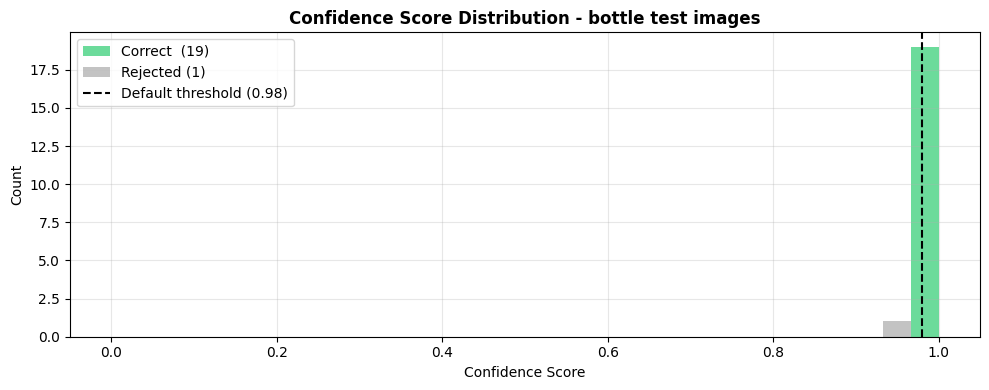

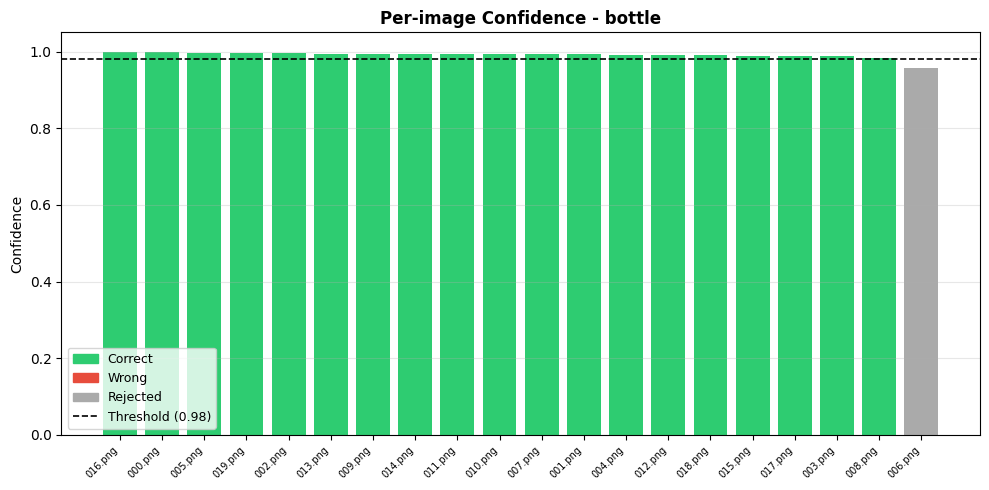

Computing PCA embedding space ...


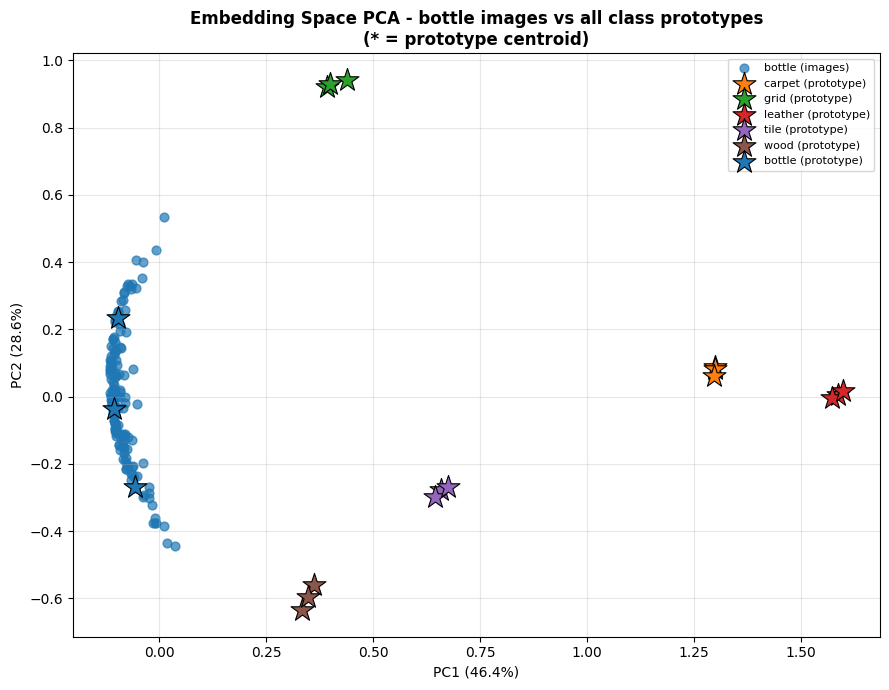

Visualisations saved to /content/drive/MyDrive/Colab Notebooks/ICT304/future_integration/models


In [11]:
# -----------------------------------------------------------------------
# 1. Confidence distribution
# -----------------------------------------------------------------------
correct_c  = [c for p, g, c in zip(preds, gt_names, confs) if p == g]
wrong_c    = [c for p, g, c in zip(preds, gt_names, confs)
              if p not in ('unknown', 'ambiguous') and p != g]
rejected_c = [c for p, c in zip(preds, confs) if p in ('unknown', 'ambiguous')]

fig, ax = plt.subplots(figsize=(10, 4))
bins = np.linspace(0, 1, 31)
if correct_c:  ax.hist(correct_c,  bins=bins, color='#2ecc71', alpha=0.7, label=f'Correct  ({len(correct_c)})')
if wrong_c:    ax.hist(wrong_c,    bins=bins, color='#e74c3c', alpha=0.7, label=f'Wrong    ({len(wrong_c)})')
if rejected_c: ax.hist(rejected_c, bins=bins, color='#aaaaaa', alpha=0.7, label=f'Rejected ({len(rejected_c)})')
ax.axvline(CONFIDENCE_THRESHOLD, color='black', linestyle='--',
           linewidth=1.5, label=f'Default threshold ({CONFIDENCE_THRESHOLD})')
ax.set_xlabel('Confidence Score')
ax.set_ylabel('Count')
ax.set_title(f'Confidence Score Distribution - {NEW_CLASS} test images', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINT_DIR, f'confidence_distribution_{NEW_CLASS}.png'),
            dpi=150, bbox_inches='tight')
plt.show()

# -----------------------------------------------------------------------
# 2. Per-prediction bar chart (sorted by confidence)
# -----------------------------------------------------------------------
if len(preds) <= 40:  # only show individual bars if manageable number
    sorted_data = sorted(zip(paths_out, preds, confs, gt_names),
                         key=lambda x: x[2], reverse=True)
    fnames  = [os.path.basename(x[0])[:20] for x in sorted_data]
    s_confs = [x[2] for x in sorted_data]
    colors  = ['#2ecc71' if x[1]==x[3] else ('#aaaaaa' if x[1] in ('unknown','ambiguous') else '#e74c3c')
               for x in sorted_data]

    fig, ax = plt.subplots(figsize=(max(10, len(fnames)*0.5), 5))
    bars = ax.bar(range(len(fnames)), s_confs, color=colors)
    ax.axhline(CONFIDENCE_THRESHOLD, color='black', linestyle='--', linewidth=1.2,
               label=f'Threshold ({CONFIDENCE_THRESHOLD})')
    ax.set_xticks(range(len(fnames)))
    ax.set_xticklabels(fnames, rotation=45, ha='right', fontsize=7)
    ax.set_ylabel('Confidence')
    ax.set_ylim(0, 1.05)
    ax.set_title(f'Per-image Confidence - {NEW_CLASS}', fontsize=12, fontweight='bold')
    p1 = mpatches.Patch(color='#2ecc71', label='Correct')
    p2 = mpatches.Patch(color='#e74c3c', label='Wrong')
    p3 = mpatches.Patch(color='#aaaaaa', label='Rejected')
    ax.legend(handles=[p1, p2, p3, ax.get_lines()[0]], fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig(os.path.join(CHECKPOINT_DIR, f'per_image_confidence_{NEW_CLASS}.png'),
                dpi=150, bbox_inches='tight')
    plt.show()

# -----------------------------------------------------------------------
# 3. Embedding PCA - new class vs existing class prototypes
# -----------------------------------------------------------------------
print('Computing PCA embedding space ...')

@torch.no_grad()
def get_embeddings_for_samples(model, samples, device, max_n=150):
    model.eval()
    sampled = random.sample(samples, min(len(samples), max_n))
    embs, labs = [], []
    for path, cls in sampled:
        try:
            img = val_transform(Image.open(path).convert('RGB')).unsqueeze(0).to(device)
            e   = model(img, return_embedding=True).squeeze(0).cpu().numpy()
            embs.append(e)
            labs.append(cls)
        except Exception:
            continue
    return np.array(embs), labs


all_new_samples = new_train_samples + new_test_samples
embs_np, emb_labels = get_embeddings_for_samples(model, all_new_samples, DEVICE)

if len(embs_np) > 5:
    # Collect prototype centroids from all classes in bank for comparison
    proto_embs, proto_labels = [], []
    for idx, protos in bank.prototypes.items():
        for proto in protos:
            proto_embs.append(proto.numpy())
            proto_labels.append(bank.idx_to_class[idx])

    combined_embs   = np.vstack([embs_np, np.array(proto_embs)])
    combined_labels = emb_labels + proto_labels

    pca = PCA(n_components=2, random_state=SEED)
    pts = pca.fit_transform(combined_embs)

    n_img   = len(embs_np)
    n_proto = len(proto_embs)

    unique_classes = sorted(set(combined_labels))
    palette   = sns.color_palette('tab10', len(unique_classes))
    cls_color = {cls: c for cls, c in zip(unique_classes, palette)}

    fig, ax = plt.subplots(figsize=(9, 7))

    # Plot new class image embeddings
    nc_idx = [i for i, l in enumerate(emb_labels) if l == NEW_CLASS]
    if nc_idx:
        ax.scatter(pts[nc_idx, 0], pts[nc_idx, 1],
                   color=cls_color[NEW_CLASS], label=f'{NEW_CLASS} (images)',
                   marker='o', s=40, alpha=0.7)

    # Plot prototype centroids as stars
    for i, (cls, pt) in enumerate(zip(proto_labels, pts[n_img:])):
        label_str = f'{cls} (prototype)' if i == proto_labels.index(cls) else None
        ax.scatter(pt[0], pt[1],
                   color=cls_color[cls],
                   marker='*', s=300,
                   edgecolors='black', linewidths=0.8,
                   label=label_str, zorder=10)

    # Deduplicate legend
    handles, labels_leg = ax.get_legend_handles_labels()
    seen = set()
    unique_h, unique_l = [], []
    for h, l in zip(handles, labels_leg):
        if l not in seen and l is not None:
            seen.add(l)
            unique_h.append(h)
            unique_l.append(l)

    ax.set_title(
        f'Embedding Space PCA - {NEW_CLASS} images vs all class prototypes\n'
        f'(* = prototype centroid)',
        fontsize=12, fontweight='bold'
    )
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    ax.legend(handles=unique_h, labels=unique_l, fontsize=8, loc='best')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(CHECKPOINT_DIR, f'embedding_pca_{NEW_CLASS}.png'),
                dpi=150, bbox_inches='tight')
    plt.show()

print('Visualisations saved to', CHECKPOINT_DIR)

## STEP 11 - Anomaly Detection: Train STFPM for New Class

We train a STFPM (Student-Teacher Feature Pyramid Matching) anomaly detector for the new class.  
This is identical to how the existing per-class models were trained (stfpm_wood.ckpt, etc.).

No augmentation is used - normal images only.  
The model returns:
- `pred_label` - 0 = Normal, 1 = Anomalous
- `pred_score` - confidence score (0 to 1)
- `anomaly_map` - pixel-level heatmap mask

Training is two-phase:
1. A 50-epoch probe to find the optimal stopping point
2. A final clean training run to that exact epoch count

### 11a - Prepare Data in MVTec Layout

Anomalib's MVTecAD datamodule expects a specific folder layout. We copy the new class images into that structure temporarily.

### 11b - Phase 1: 50-Epoch Probe to Find Optimal Epoch Count

In [ ]:
import os
from anomalib.data import MVTecAD
from anomalib.models import Stfpm
from anomalib.engine import Engine
from anomalib.metrics import AUROC, F1Max, Evaluator
from lightning.pytorch.loggers import CSVLogger


ANOM_DATA_PARENT = DATASET_ROOT  # e.g. /content/drive/MyDrive/.../dataset
CLASS_NAME = NEW_CLASS

# Sanity check
dest = os.path.join(ANOM_DATA_PARENT, CLASS_NAME)
print("Expected class path:", dest)
print("Train exists:       ", os.path.exists(os.path.join(dest, "train")))
print("Test exists:        ", os.path.exists(os.path.join(dest, "test")))
print("Ground truth exists:", os.path.exists(os.path.join(dest, "ground_truth")))

def make_datamodule(root, category):
    return MVTecAD(
        root=root,
        category=category,
        train_batch_size=16,
        eval_batch_size=256,
        num_workers=2,
    )

def make_evaluator():
    return Evaluator(
        val_metrics=[
            AUROC(fields=["pred_score", "gt_label"]),
            F1Max(fields=["pred_score", "gt_label"]),
        ]
    )

PROBE_LOG_DIR = os.path.join(LOG_DIR, "probe")
os.makedirs(PROBE_LOG_DIR, exist_ok=True)

print(f'\nPhase 1: 50-epoch probe for "{CLASS_NAME}" ...')

model_stfpm_probe = Stfpm(evaluator=make_evaluator())

engine_probe = Engine(
    max_epochs=50,
    logger=CSVLogger(PROBE_LOG_DIR, name="metrics", version="0"),
)

dm_probe = make_datamodule(ANOM_DATA_PARENT, CLASS_NAME)

engine_probe.fit(model=model_stfpm_probe, datamodule=dm_probe)
engine_probe.test(model=model_stfpm_probe, datamodule=dm_probe)

print("Probe training complete.")

Expected class path: /content/drive/MyDrive/Colab Notebooks/ICT304/dataset/bottle
Train exists:        True
Test exists:         True
Ground truth exists: True

Phase 1: 50-epoch probe for "bottle" ...


INFO:lightning_fabric.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:lightning_fabric.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:lightning_fabric.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name           ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ pre_processor  │ PreProcessor  │      0 │ train │     0 │
│ 1 │ post_processor │ PostProcessor │      0 │ train │     0 │
│ 2 │ evaluator      │ Evaluator     │      0 │ train │     0 │
│ 3 │ model          │ STFPMModel    │  5.6 M │ train │     0 │
│ 4 │ loss           │ STFPMLoss     │      0 │ train │     0 │
└───┴────────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 2.8 M                                                                                            
Non-trainable params: 2.8 M                                                                                        
Total params: 5.6 M                                                                                                
Total estimated model params size (MB): 22                                                                         
Modules in train mode: 88                                                                                          
Modules in eval mode: 69                                                                                           
Total FLOPs: 0

Output()

INFO:lightning_fabric.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=50` reached.


INFO:lightning_fabric.utilities.rank_zero:The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: Evaluator, ImageVisualizer, PostProcessor, PreProcessor
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

Probe training complete.


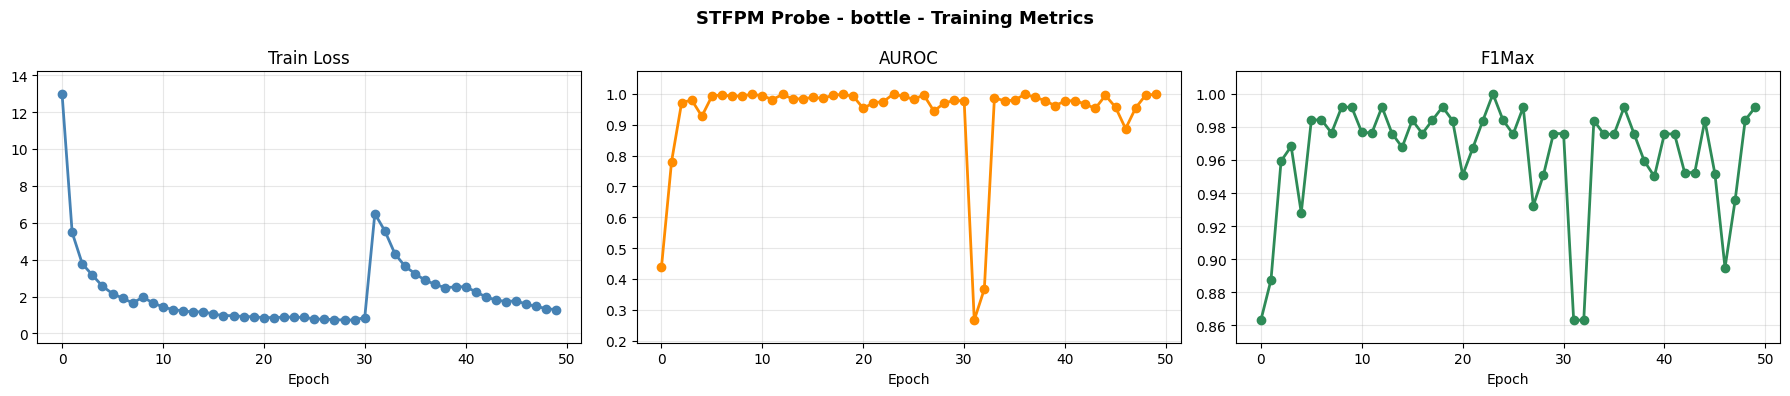


Best epoch (by AUROC): 24

Optimal epoch count: 24
You can override OPTIMAL_EPOCHS in the next cell if needed.


In [ ]:
def plot_stfpm_metrics(log_dir, model_name):
    """Plot training metrics from CSVLogger output and return best epoch."""
    metrics_path = os.path.join(log_dir, 'metrics', '0', 'metrics.csv')
    if not os.path.exists(metrics_path):
        print(f'  Metrics file not found: {metrics_path}')
        return 25

    df = pd.read_csv(metrics_path)
    train_df = df[df['train_loss_epoch'].notna()][['epoch','train_loss_epoch']].reset_index(drop=True)
    val_cols  = [c for c in df.columns
                 if c not in ('epoch','step','train_loss_epoch','train_loss_step')]
    val_df    = df[df[val_cols[0]].notna()][['epoch'] + val_cols].reset_index(drop=True) \
                if val_cols else None

    n_plots = (1 if not train_df.empty else 0) + (len(val_cols) if val_df is not None else 0)
    if n_plots == 0:
        return 25

    fig, axes = plt.subplots(1, n_plots, figsize=(6*n_plots, 4))
    if n_plots == 1:
        axes = [axes]

    ax_idx = 0
    if not train_df.empty:
        axes[ax_idx].plot(train_df['epoch'], train_df['train_loss_epoch'],
                          marker='o', color='steelblue', linewidth=2)
        axes[ax_idx].set_title('Train Loss')
        axes[ax_idx].set_xlabel('Epoch')
        axes[ax_idx].grid(True, alpha=0.3)
        ymin, ymax = train_df['train_loss_epoch'].min(), train_df['train_loss_epoch'].max()
        m = (ymax - ymin) * 0.1 or 0.1
        axes[ax_idx].set_ylim(ymin - m, ymax + m)
        ax_idx += 1

    colours = ['darkorange', 'seagreen', 'purple', 'crimson']
    best_epoch = 25
    if val_df is not None:
        for col, colour in zip(val_cols, colours):
            data = val_df[['epoch', col]].dropna()
            axes[ax_idx].plot(data['epoch'], data[col], marker='o', color=colour, linewidth=2)
            axes[ax_idx].set_title(col)
            axes[ax_idx].set_xlabel('Epoch')
            axes[ax_idx].grid(True, alpha=0.3)
            ymin, ymax = data[col].min(), data[col].max()
            m = (ymax - ymin) * 0.1 or 0.01
            axes[ax_idx].set_ylim(ymin - m, ymax + m)
            ax_idx += 1
        best_row   = val_df.loc[val_df[val_cols[0]].idxmax()]
        best_epoch = int(best_row['epoch']) + 1

    fig.suptitle(f'{model_name} - Training Metrics', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(STFPM_MODEL_DIR, f'stfpm_{NEW_CLASS}_probe_metrics.png'),
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f'\nBest epoch (by {val_cols[0] if val_cols else "loss"}): {best_epoch}')
    return best_epoch


OPTIMAL_EPOCHS = plot_stfpm_metrics(PROBE_LOG_DIR, f'STFPM Probe - {NEW_CLASS}')
print(f'\nOptimal epoch count: {OPTIMAL_EPOCHS}')
print('You can override OPTIMAL_EPOCHS in the next cell if needed.')

### 11c - Phase 2: Final Training to Optimal Epoch Count

Uncomment and set `OPTIMAL_EPOCHS` manually below if you want to override the auto-detected value.

In [ ]:
# Override if needed:
OPTIMAL_EPOCHS = 30

print(f'Phase 2: Final STFPM training for "{NEW_CLASS}" ({OPTIMAL_EPOCHS} epochs) ...')

model_stfpm_final = Stfpm()
engine_final      = Engine(max_epochs=OPTIMAL_EPOCHS)

dm_final = make_datamodule(DATASET_ROOT, NEW_CLASS)
engine_final.fit(model=model_stfpm_final, datamodule=dm_final)

STFPM_SAVE_PATH = os.path.join(STFPM_MODEL_DIR, f'stfpm_{NEW_CLASS}.ckpt')
engine_final.trainer.save_checkpoint(STFPM_SAVE_PATH)
print(f'\nSTFPM model saved : {STFPM_SAVE_PATH}')

print('\nRunning test evaluation ...')
engine_final.test(model=model_stfpm_final, datamodule=dm_final)

Phase 2: Final STFPM training for "bottle" (30 epochs) ...


INFO:lightning_fabric.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:lightning_fabric.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:lightning_fabric.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name           ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ pre_processor  │ PreProcessor  │      0 │ train │     0 │
│ 1 │ post_processor │ PostProcessor │      0 │ train │     0 │
│ 2 │ evaluator      │ Evaluator     │      0 │ train │     0 │
│ 3 │ model          │ STFPMModel    │  5.6 M │ train │     0 │
│ 4 │ loss           │ STFPMLoss     │      0 │ train │     0 │
└───┴────────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 2.8 M                                                                                            
Non-trainable params: 2.8 M                                                                                        
Total params: 5.6 M                                                                                                
Total estimated model params size (MB): 22                                                                         
Modules in train mode: 89                                                                                          
Modules in eval mode: 69                                                                                           
Total FLOPs: 0

Output()

...

INFO: `weights_only` was not set, defaulting to `False`.
INFO:lightning.pytorch.trainer.connectors.checkpoint_connector:`weights_only` was not set, defaulting to `False`.
INFO:lightning_fabric.utilities.rank_zero:The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: Evaluator, ImageVisualizer, PostProcessor, PreProcessor
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



STFPM model saved : /content/drive/MyDrive/Colab Notebooks/ICT304/future_integration/models/stfpm/stfpm_bottle.ckpt

Running test evaluation ...


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│        image_AUROC        │    0.9738094806671143     │
│       image_F1Score       │    0.9672130942344666     │
│        pixel_AUROC        │    0.9271765351295471     │
│       pixel_F1Score       │    0.47057369351387024    │
└───────────────────────────┴───────────────────────────┘

[{'image_AUROC': 0.9738094806671143,
  'image_F1Score': 0.9672130942344666,
  'pixel_AUROC': 0.9271765351295471,
  'pixel_F1Score': 0.47057369351387024}]

## STEP 12 - Anomaly Detection Inference and Visualisation

Run inference on the test images. Each prediction returns:
- Normal or Anomalous label
- Confidence score
- Pixel-level anomaly map

Results are shown as: original image | anomaly heatmap | blended overlay.

Running anomaly detection inference ...


INFO:lightning_fabric.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:lightning_fabric.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:lightning_fabric.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning_fabric.utilities.rank_zero:Restoring states from the checkpoint path at /content/drive/MyDrive/Colab Notebooks/ICT304/future_integration/models/stfpm/stfpm_bottle.ckpt
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning_fabric.utilities.rank_zero:Loaded model weights from the checkpoint at /content/drive/MyDrive/Colab Notebooks/ICT304/future_integration/models/stfpm/stfpm_bottle.ckpt


Output()


Results for "bottle" test images:
-------------------------------------------------------
  ✓ 000.png                         gt=ANOMALOUS   pred=ANOMALOUS   conf=89.16%
  ✓ 001.png                         gt=ANOMALOUS   pred=ANOMALOUS   conf=99.27%
  ✓ 002.png                         gt=ANOMALOUS   pred=ANOMALOUS   conf=75.49%
  ✓ 003.png                         gt=ANOMALOUS   pred=ANOMALOUS   conf=84.29%
  ✓ 004.png                         gt=ANOMALOUS   pred=ANOMALOUS   conf=100.00%
  ✓ 005.png                         gt=ANOMALOUS   pred=ANOMALOUS   conf=100.00%
  ✓ 006.png                         gt=ANOMALOUS   pred=ANOMALOUS   conf=100.00%
  ✓ 007.png                         gt=ANOMALOUS   pred=ANOMALOUS   conf=64.71%
  ✓ 008.png                         gt=ANOMALOUS   pred=ANOMALOUS   conf=83.54%
  ✓ 009.png                         gt=ANOMALOUS   pred=ANOMALOUS   conf=96.15%
  ✓ 010.png                         gt=ANOMALOUS   pred=ANOMALOUS   conf=68.53%
  ✓ 011.png               

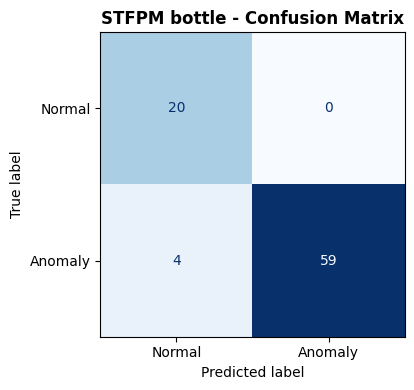

In [ ]:
from anomalib.post_processing import PostProcessor
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print('Running anomaly detection inference ...')

dm_infer = make_datamodule(DATASET_ROOT, CLASS_NAME)

model_infer  = Stfpm()
engine_infer = Engine()

predictions = engine_infer.predict(
    model=model_infer,
    datamodule=dm_infer,
    ckpt_path=STFPM_SAVE_PATH,
)

print(f'\nResults for "{NEW_CLASS}" test images:')
print('-' * 55)

pred_records = []
for pred in predictions:
    for i in range(len(pred.image_path)):
        path      = pred.image_path[i]
        score     = float(pred.pred_score[i])
        gt_lbl    = int(pred.gt_label[i]) if pred.gt_label is not None else -1
        pred_lbl  = int(bool(pred.pred_label[i]))
        label_str = 'ANOMALOUS' if pred_lbl else 'Normal'
        gt_str    = 'ANOMALOUS' if gt_lbl == 1 else 'Normal'
        correct   = '✓' if pred_lbl == gt_lbl else '✗'
        pred_records.append({'path': path, 'score': score,
                              'pred': pred_lbl, 'gt': gt_lbl})
        print(f'  {correct} {os.path.basename(path):30s}  gt={gt_str:10s}  pred={label_str:10s}  conf={score*100:.2f}%')

# Summary
total     = len(pred_records)
correct_n = sum(1 for r in pred_records if r['pred'] == r['gt'])
tp = sum(1 for r in pred_records if r['pred'] == 1 and r['gt'] == 1)
tn = sum(1 for r in pred_records if r['pred'] == 0 and r['gt'] == 0)
fp = sum(1 for r in pred_records if r['pred'] == 1 and r['gt'] == 0)
fn = sum(1 for r in pred_records if r['pred'] == 0 and r['gt'] == 1)
mean_score = np.mean([r['score'] for r in pred_records]) * 100

print('\nOverall Summary:')
print(tabulate([
    ['Total images',   total],
    ['Correct',        f'{correct_n} ({100*correct_n/total:.1f}%)'],
    ['True Positive',  f'{tp}  (defect correctly flagged)'],
    ['True Negative',  f'{tn}  (good correctly passed)'],
    ['False Positive', f'{fp}  (good wrongly flagged)'],
    ['False Negative', f'{fn}  (defect missed)'],
    ['Mean conf score',f'{mean_score:.2f}%'],
], headers=['Metric', 'Value'], tablefmt='fancy_grid'))

# Confusion matrix
cm   = confusion_matrix([r['gt'] for r in pred_records], [r['pred'] for r in pred_records])
disp = ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Anomaly'])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'STFPM {NEW_CLASS} - Confusion Matrix', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(STFPM_MODEL_DIR, f'stfpm_{NEW_CLASS}_confusion.png'), dpi=150, bbox_inches='tight')
plt.show()

## Summary

Everything is complete. Run the cell below to see a summary of all saved files.

In [ ]:
print('=' * 65)
print('COMPLETE - SUMMARY OF SAVED FILES')
print('=' * 65)

saved_files = [
    (BACKBONE_PATH,                                                      'Updated backbone metadata (weights unchanged)'),
    (BANK_PATH,                                                          'Updated multi-prototype bank (new class added)'),
    (STFPM_SAVE_PATH,                                                    f'STFPM anomaly model for "{NEW_CLASS}"'),
    (os.path.join(CHECKPOINT_DIR, f'confidence_distribution_{NEW_CLASS}.png'), 'Confidence distribution'),
    (os.path.join(CHECKPOINT_DIR, f'embedding_pca_{NEW_CLASS}.png'),           'Embedding PCA plot'),
    (os.path.join(STFPM_MODEL_DIR, f'stfpm_{NEW_CLASS}_probe_metrics.png'),    'STFPM probe training curves'),
    (os.path.join(STFPM_MODEL_DIR, f'stfpm_{NEW_CLASS}_samples.png'),          'STFPM sample predictions'),
    (os.path.join(STFPM_MODEL_DIR, f'stfpm_{NEW_CLASS}_confusion.png'),        'STFPM confusion matrix'),
]

rows = []
for path, desc in saved_files:
    status = 'OK' if os.path.exists(path) else 'NOT FOUND'
    rows.append([status, desc, os.path.basename(path)])

print(tabulate(rows, headers=['Status', 'Description', 'File'], tablefmt='fancy_grid'))

print(f'\nNew class added  : "{NEW_CLASS}"')
print(f'Total classes    : {NUM_CLASSES} - {ALL_CLASSES}')
print(f'Backbone weights : unchanged (frozen throughout)')
print(f'Bank updated     : {BANK_PATH}')
print(f'Anomaly model    : {STFPM_SAVE_PATH}')
print(f'\nRecognition - Acc={acc:.1f}%  Macro-F1={f1_mac:.1f}%  Rejected={rejected_n}/{len(preds)}')

COMPLETE - SUMMARY OF SAVED FILES
╒══════════╤════════════════════════════════════════════════╤════════════════════════════════════╕
│ Status   │ Description                                    │ File                               │
╞══════════╪════════════════════════════════════════════════╪════════════════════════════════════╡
│ OK       │ Updated backbone metadata (weights unchanged)  │ resnet18_backbone.pth              │
├──────────┼────────────────────────────────────────────────┼────────────────────────────────────┤
│ OK       │ Updated multi-prototype bank (new class added) │ bank_resnet18_multi_proto.pth      │
├──────────┼────────────────────────────────────────────────┼────────────────────────────────────┤
│ OK       │ STFPM anomaly model for "bottle"               │ stfpm_bottle.ckpt                  │
├──────────┼────────────────────────────────────────────────┼────────────────────────────────────┤
│ OK       │ Confidence distribution                        │ confidence_di